# Dataset plots

## Part A -> Per participant gaze speed and blink weights plots

In [1]:
from itertools import groupby
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.analyze import analyze_file, run_analysis
from src.blink_signal import has_blink_columns
from src.detection_config import DetectionConfig, ScenarioConfig
from src.gaze_signal import has_gaze_columns
from src.ground_truth import build_expected_blinks, build_expected_saccades
from src.io_utils import collect_csv_files
from src.plots import (
    plot_blink_signal,
    plot_detected_events,
    plot_gaze_speed,
    plot_saccade_directions,
    plot_speed_histogram,
    plot_threshold_sweep,
)
from src.reports import build_saccade_evaluation, summarize_evaluation_by_participant

In [2]:
DATA_DIR = Path("data")
files = collect_csv_files(DATA_DIR)

detection_cfg = DetectionConfig()

In [3]:
def plot_recording(samples, cfg):
    if has_gaze_columns(samples):
        plot_gaze_speed(samples, cfg)
    if has_blink_columns(samples):
        plot_blink_signal(samples, cfg)

## Participant_1

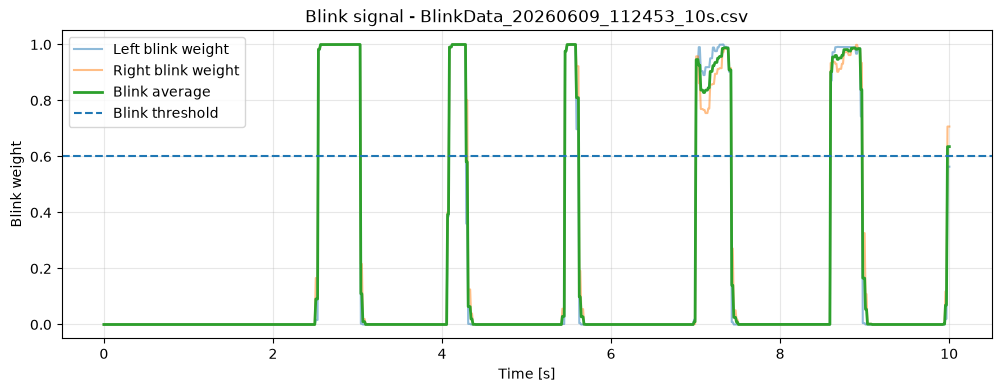

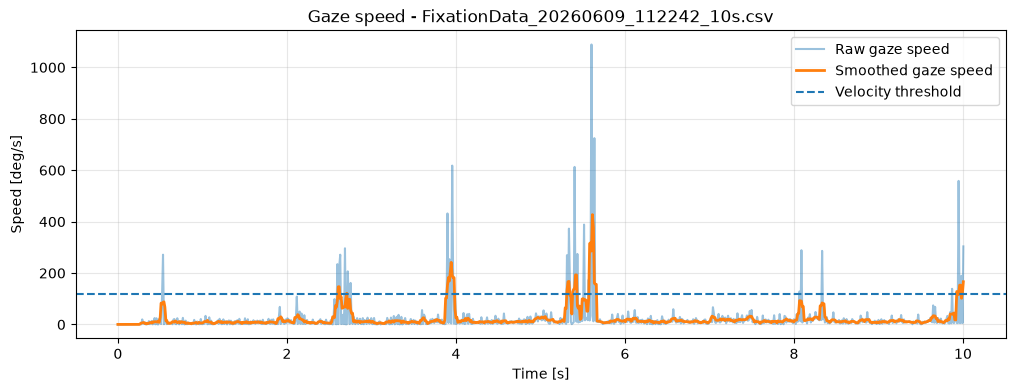

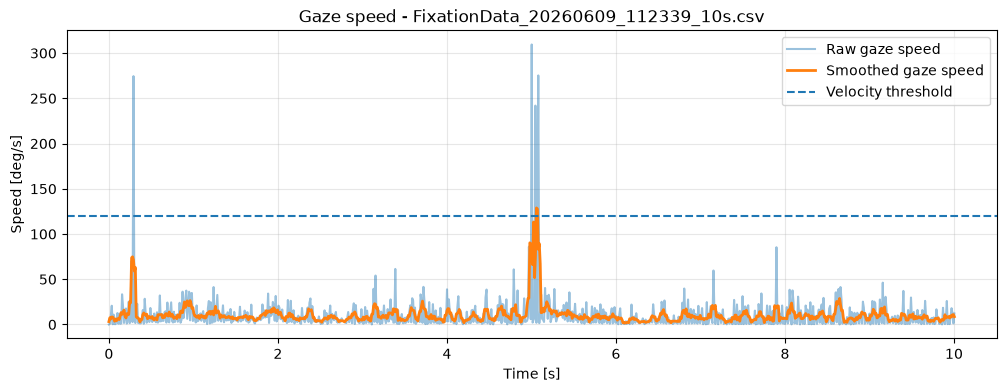

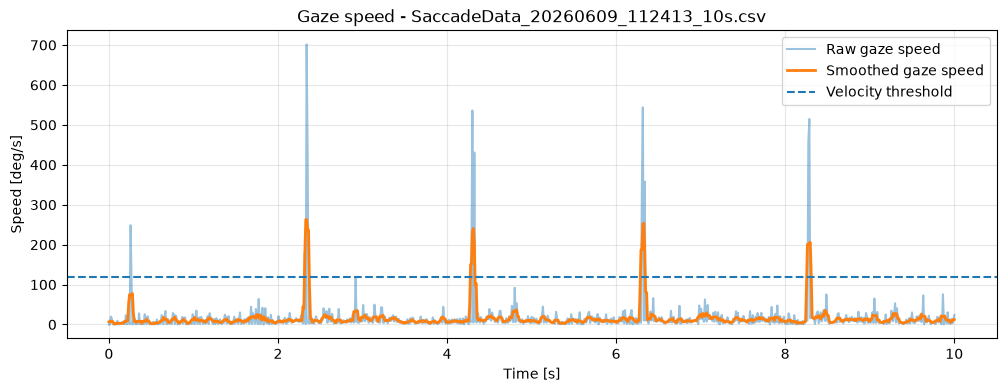

## Participant_2

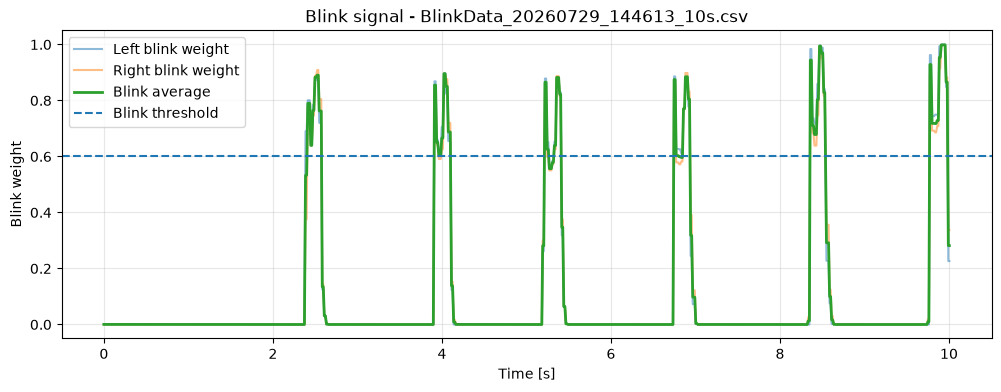

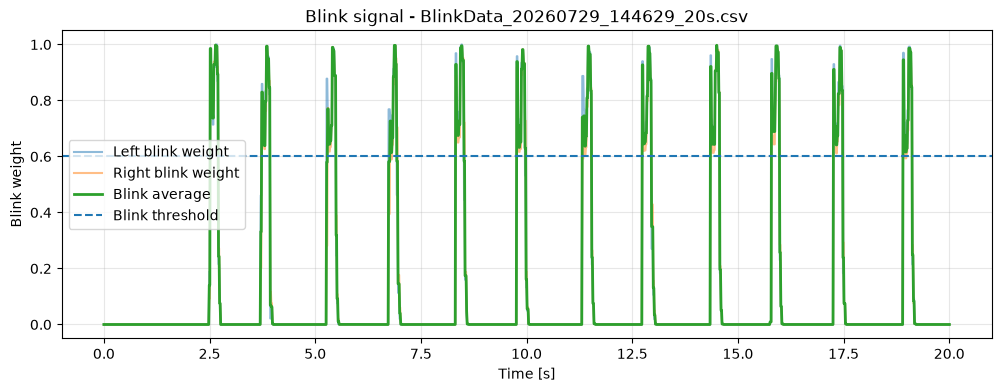

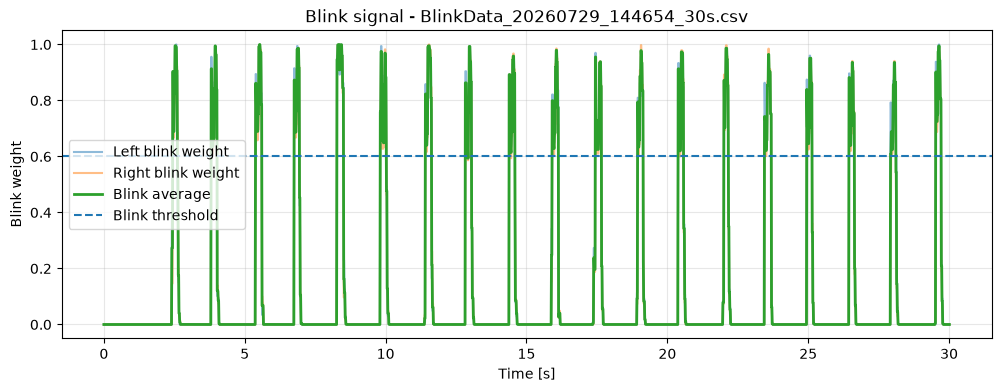

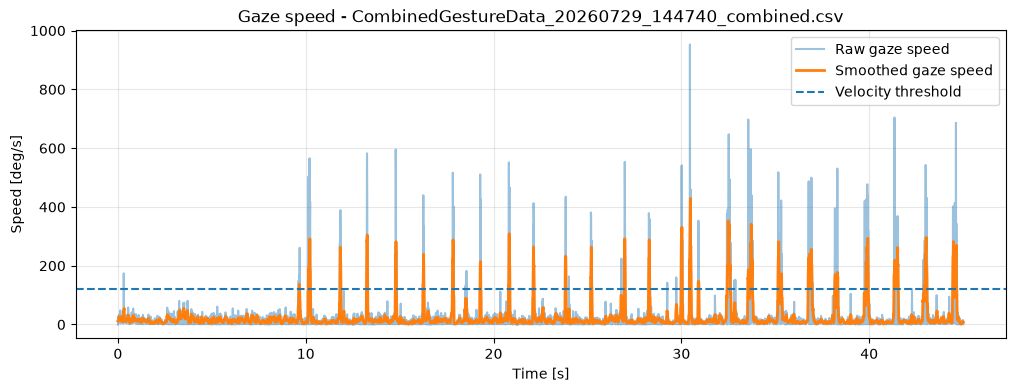

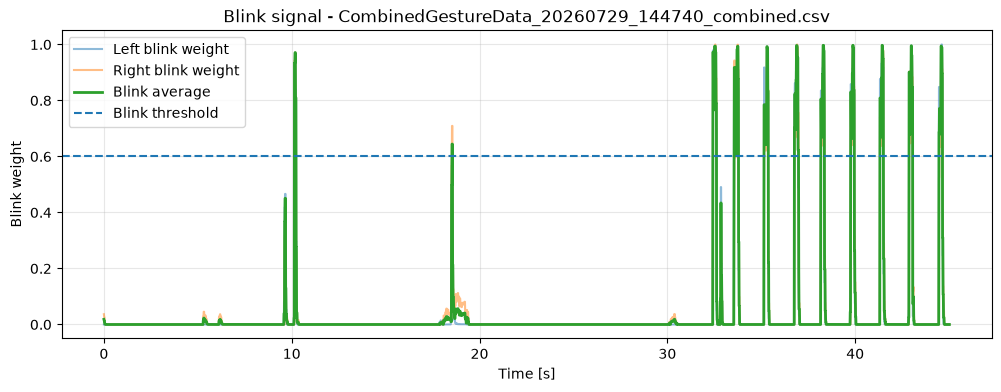

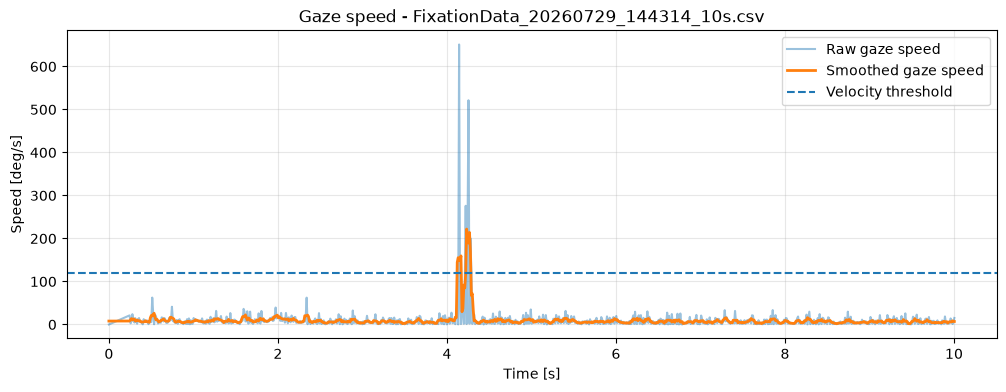

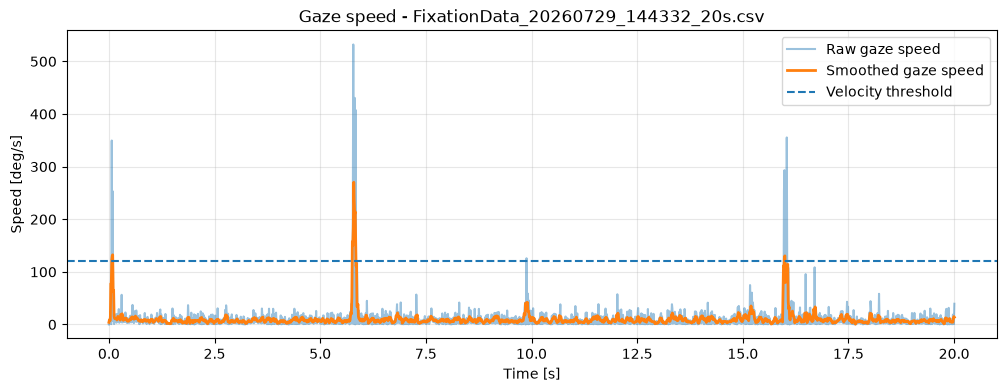

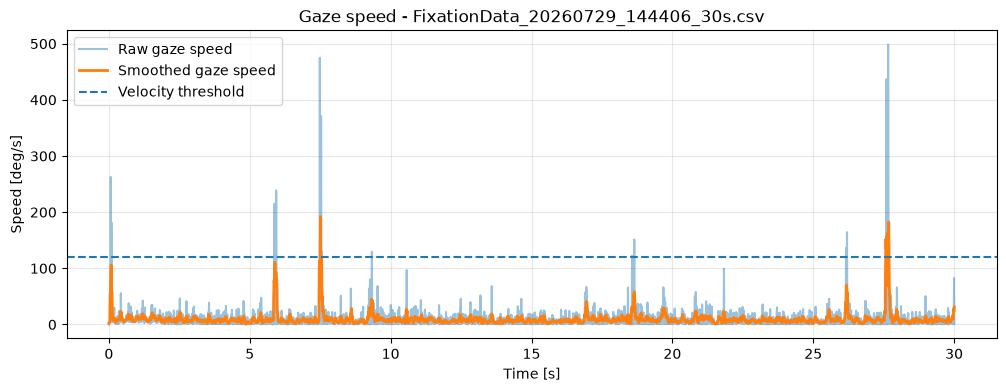

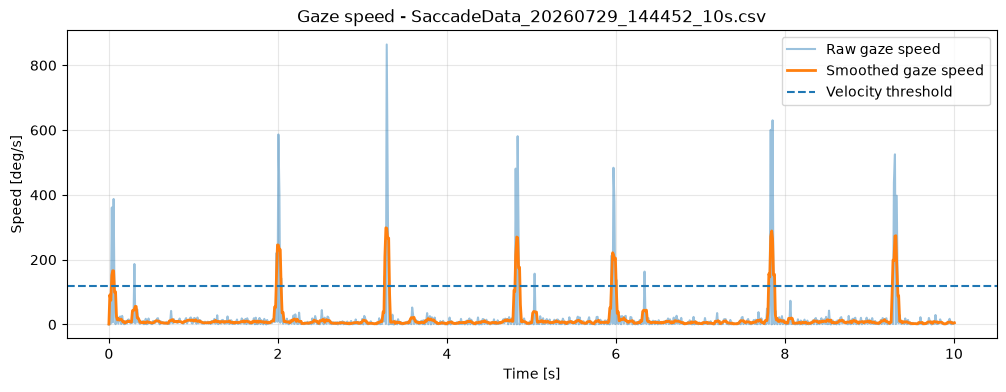

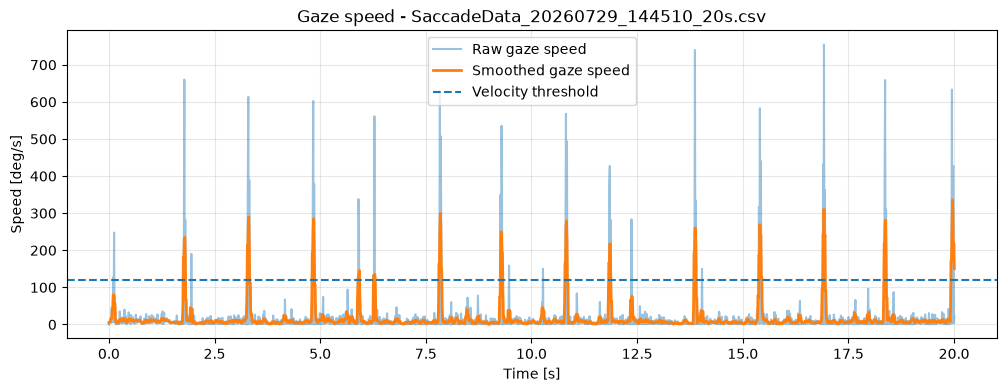

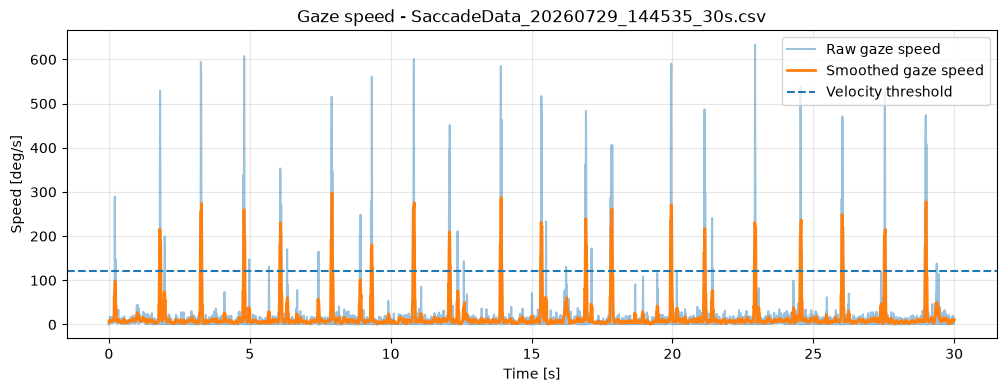

## Participant_3

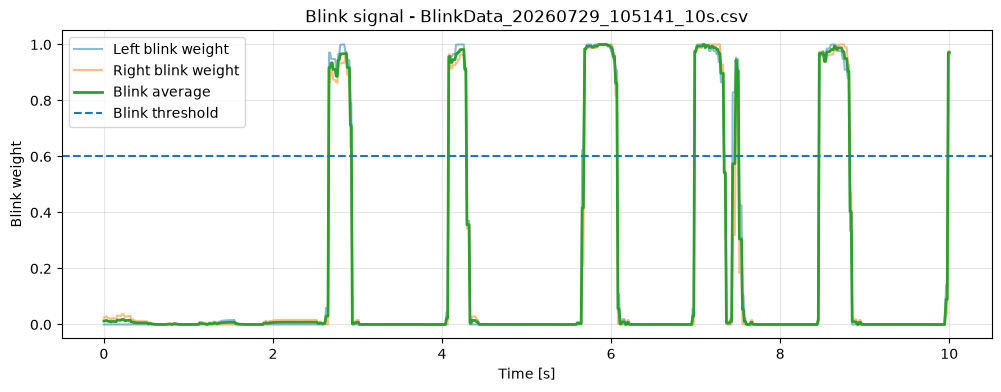

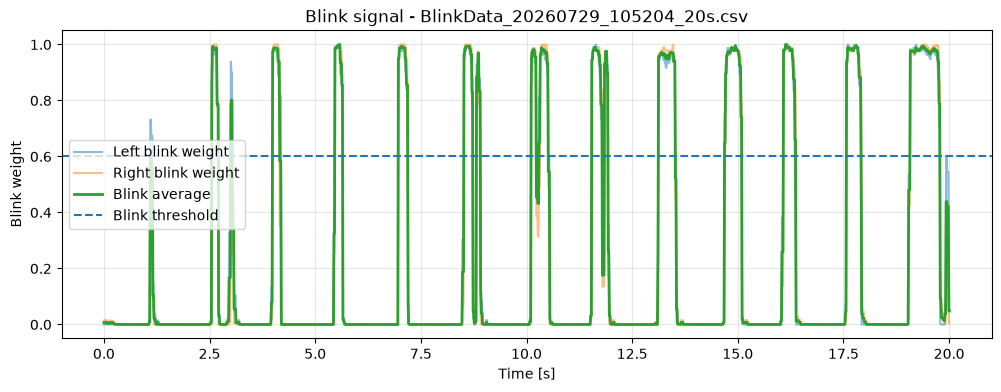

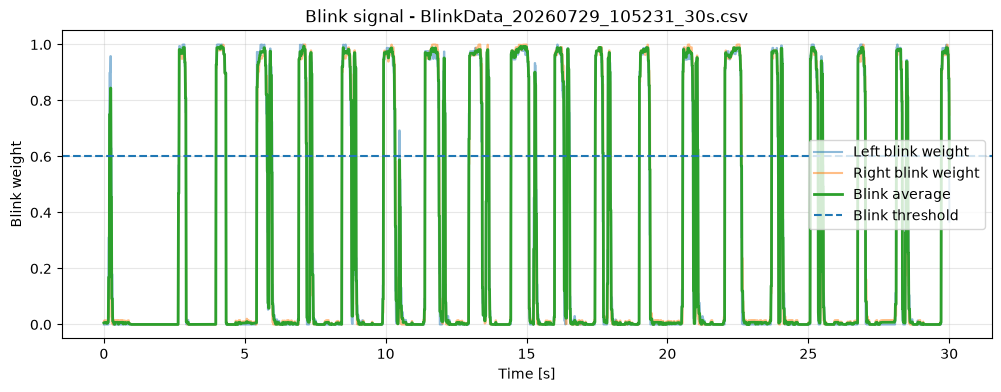

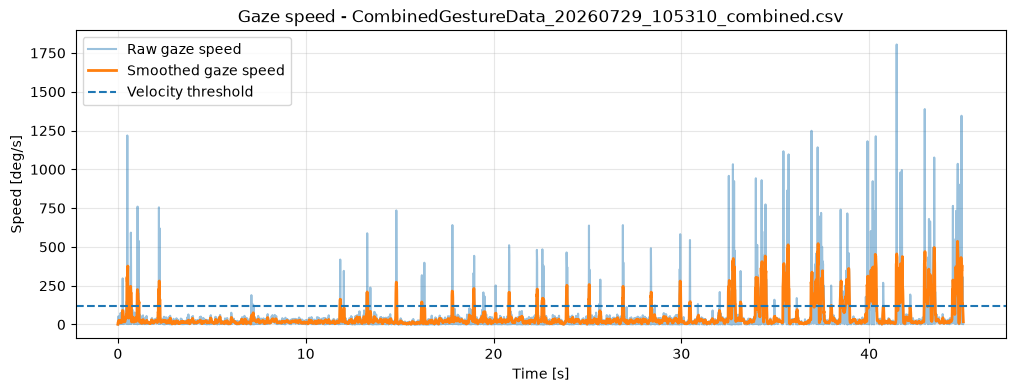

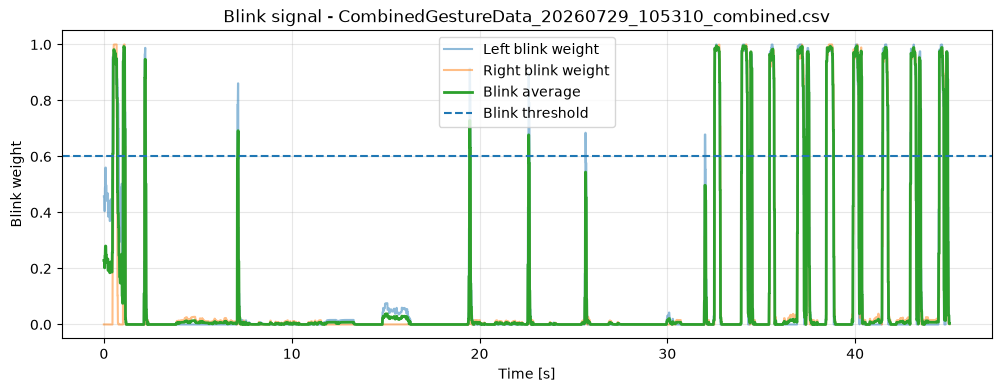

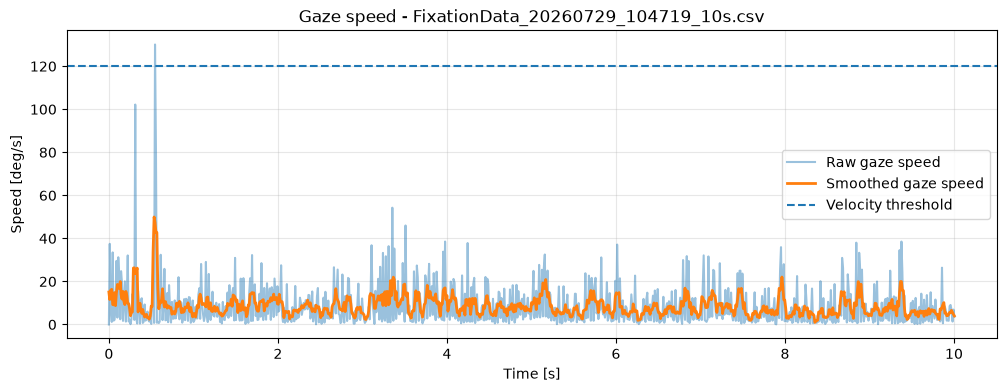

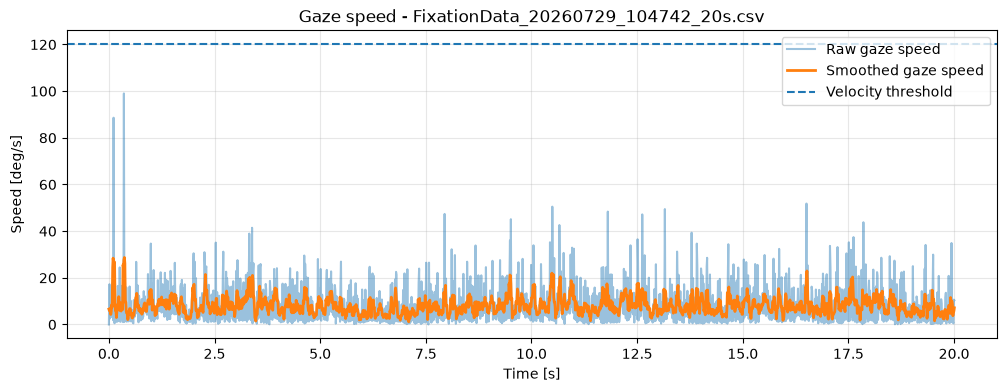

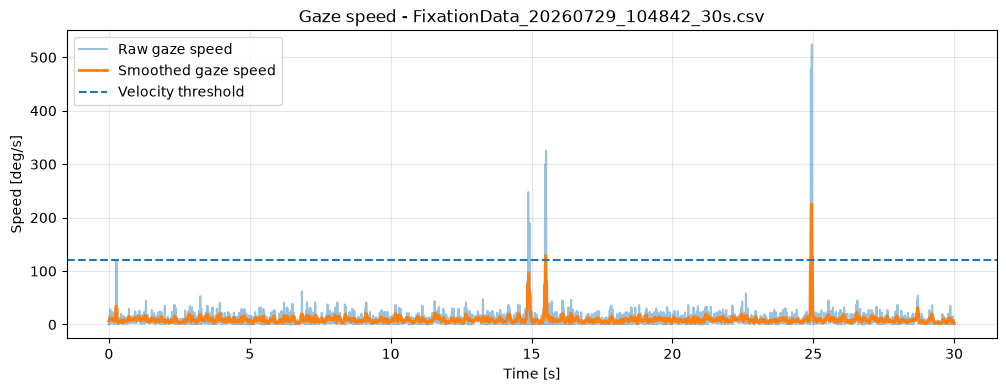

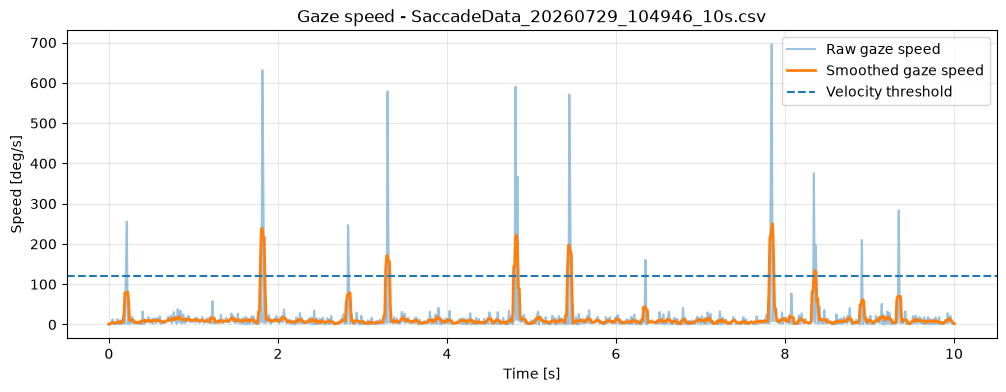

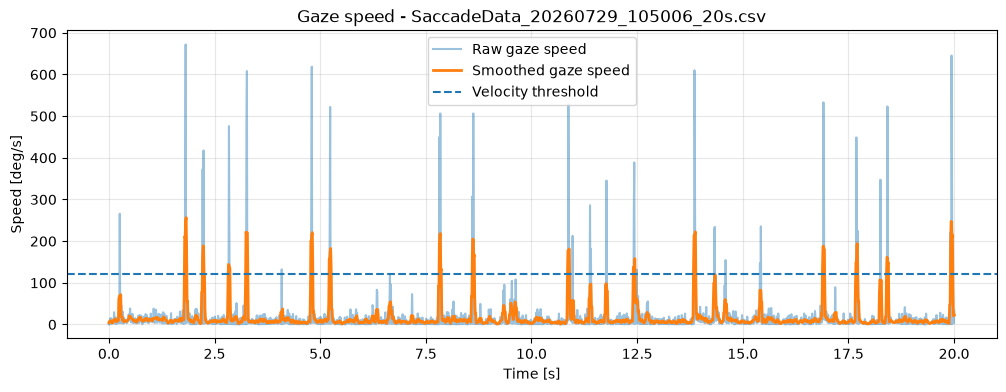

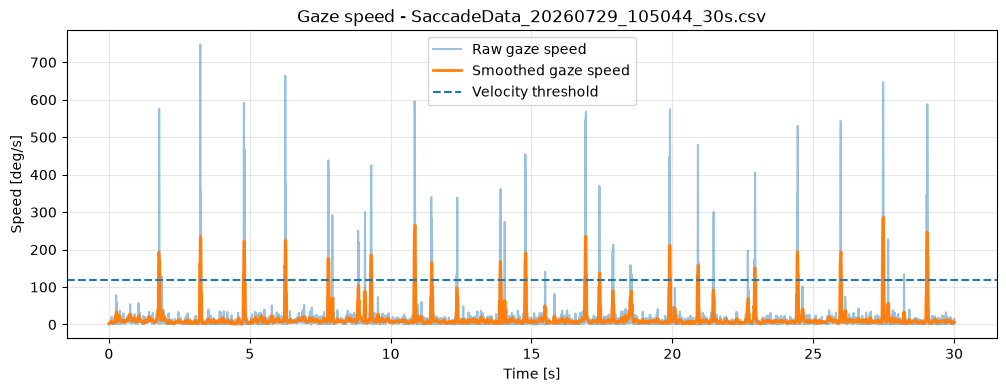

## Participant_4

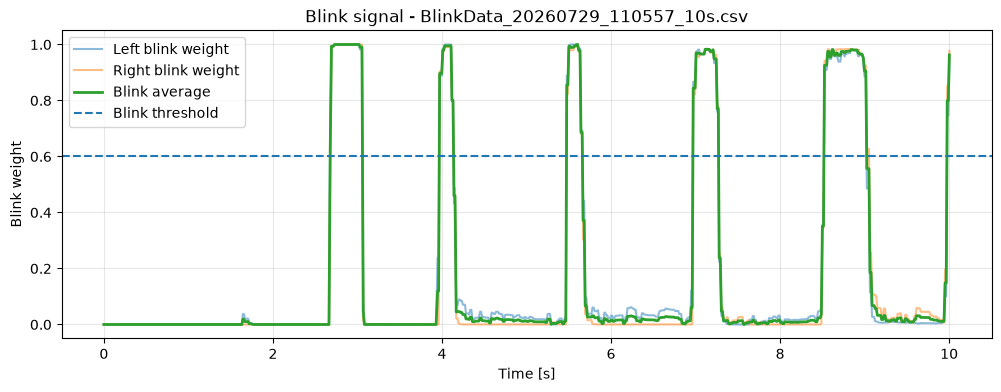

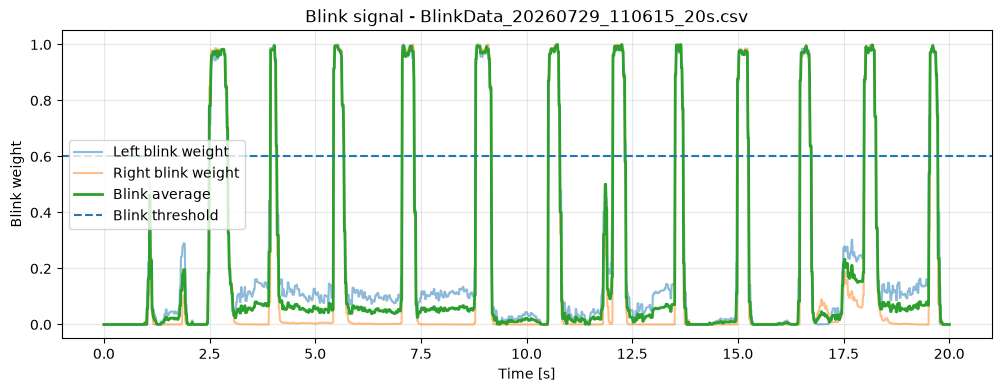

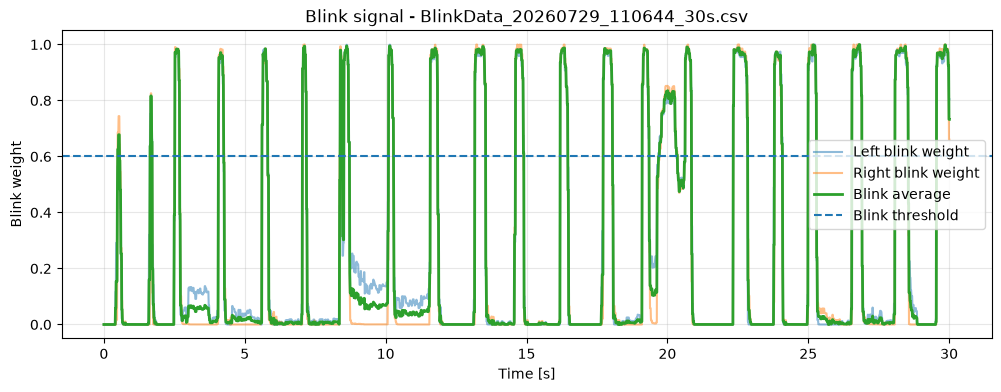

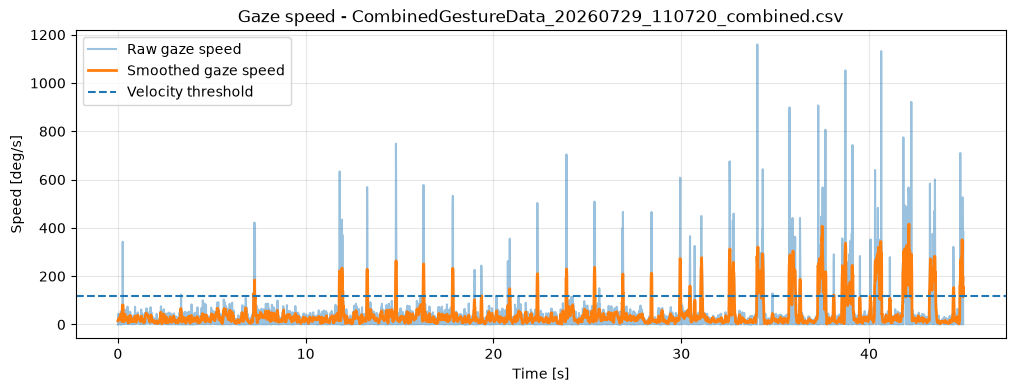

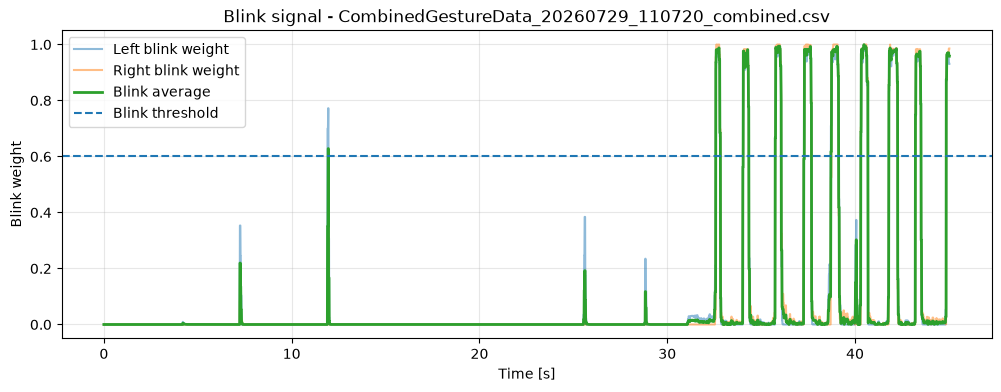

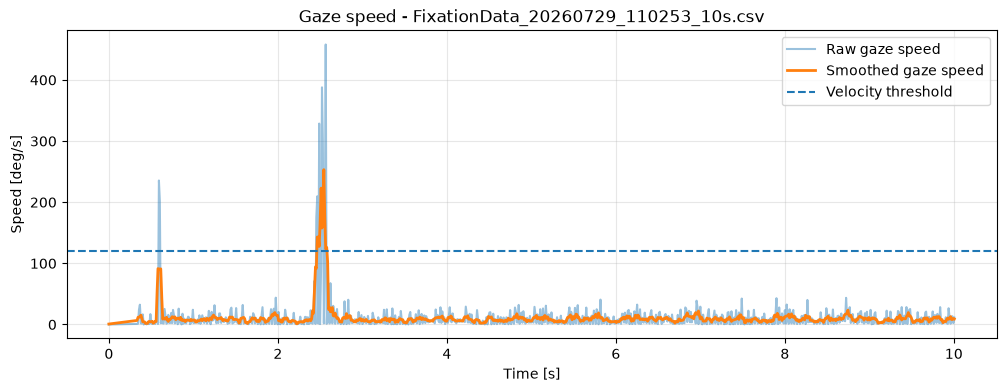

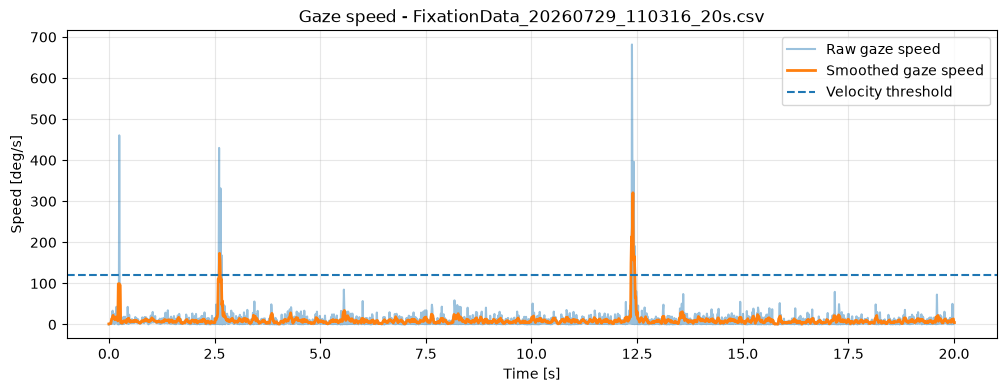

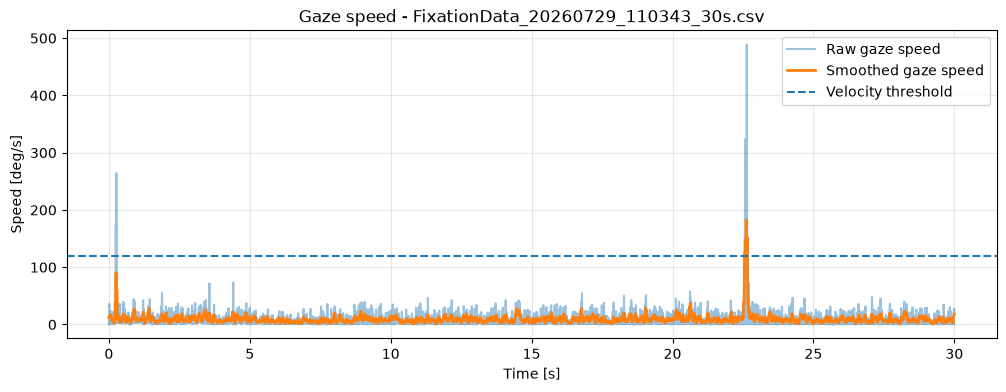

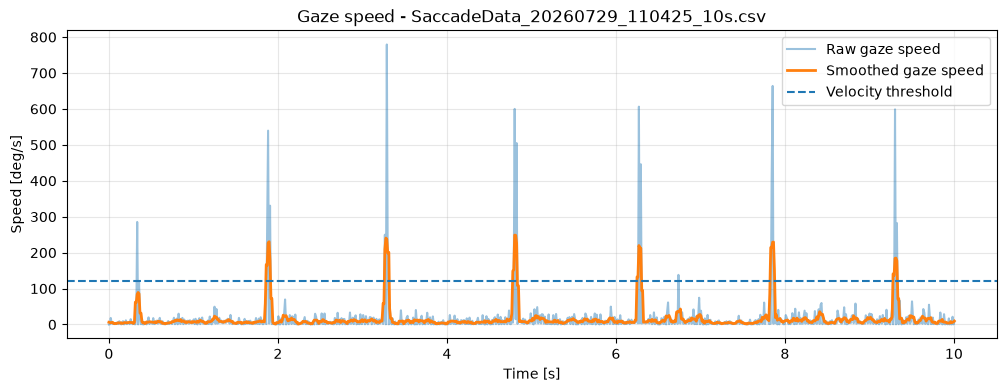

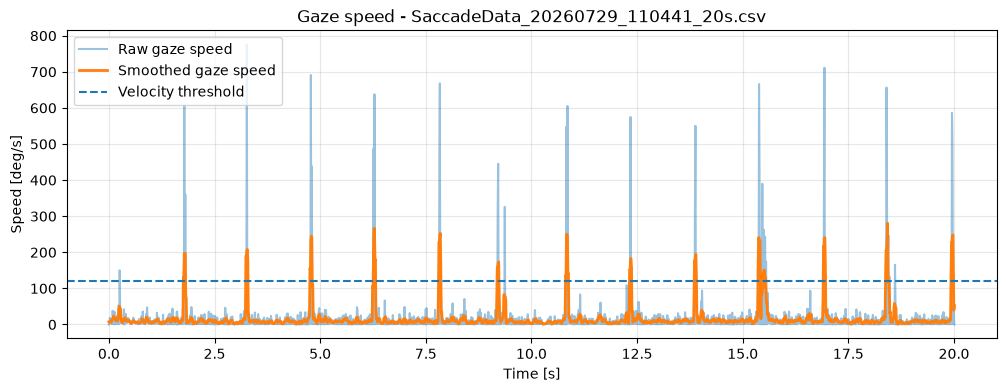

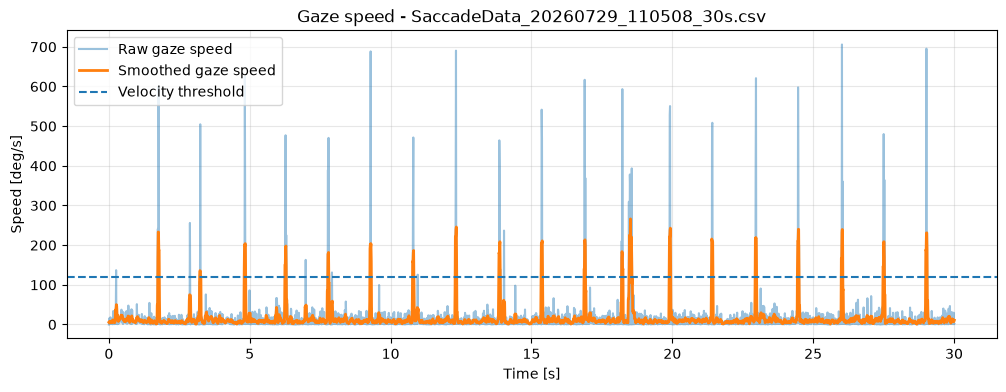

## Participant_5

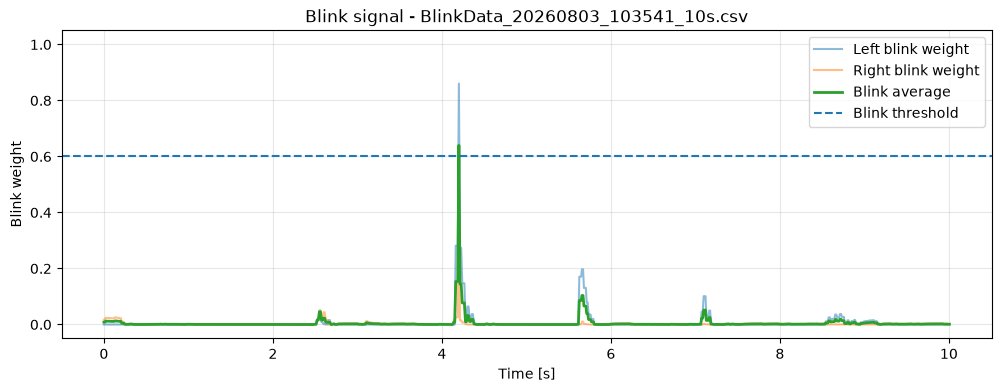

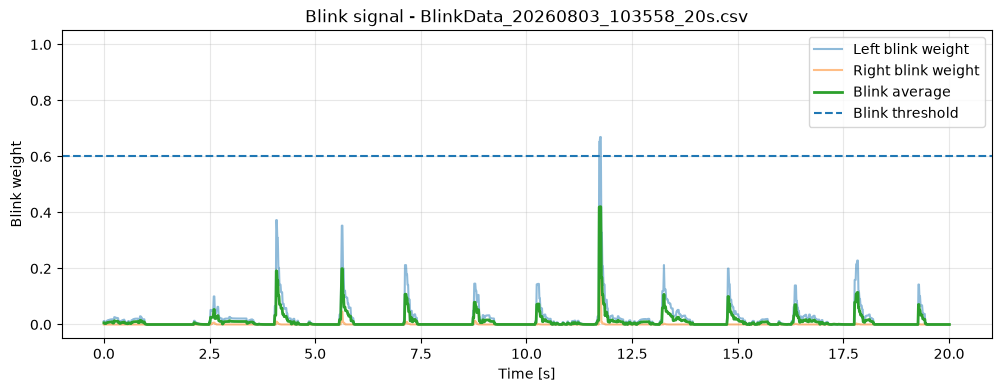

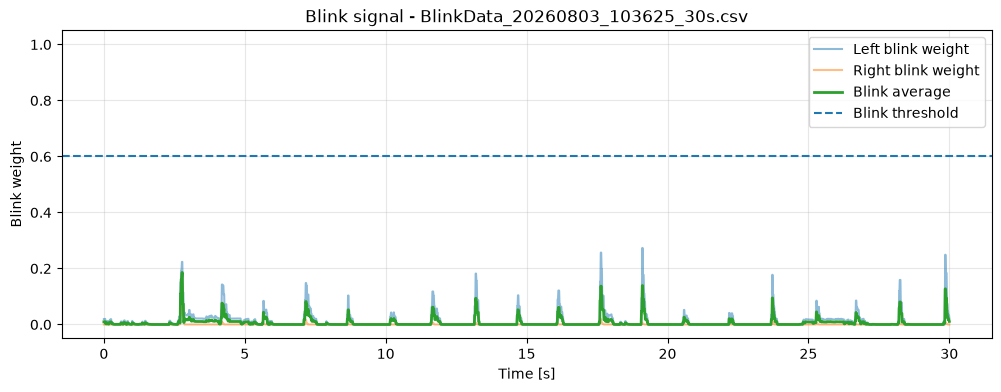

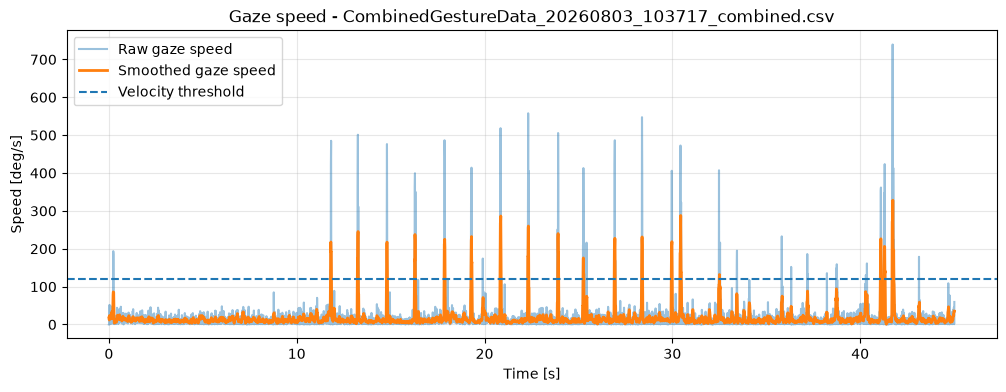

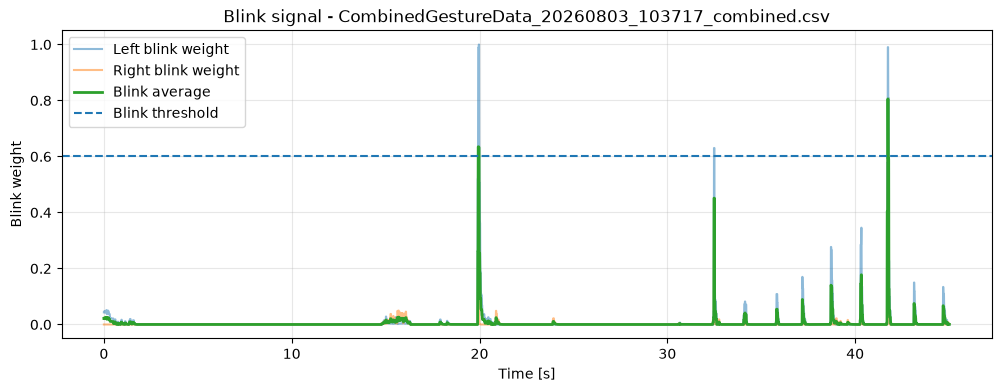

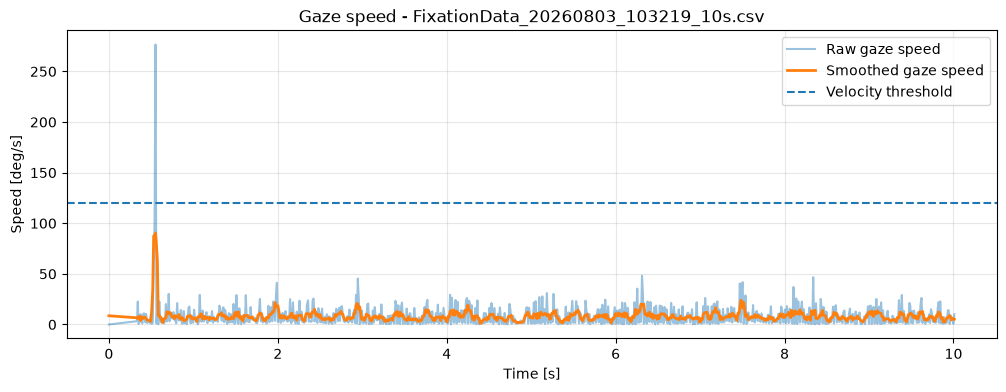

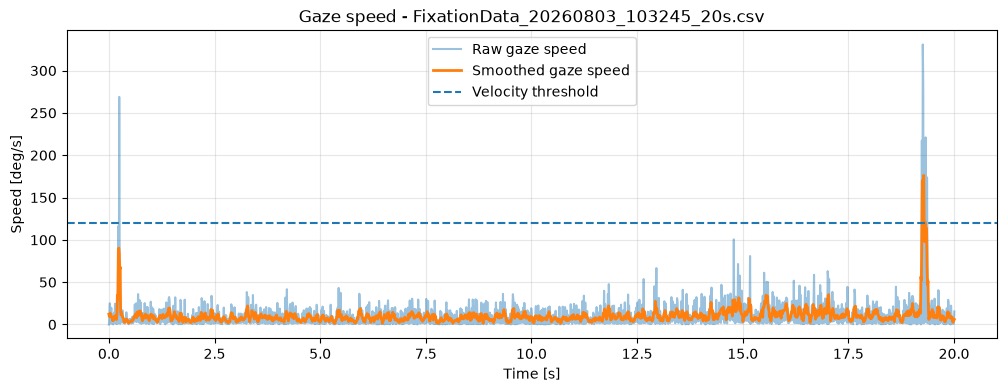

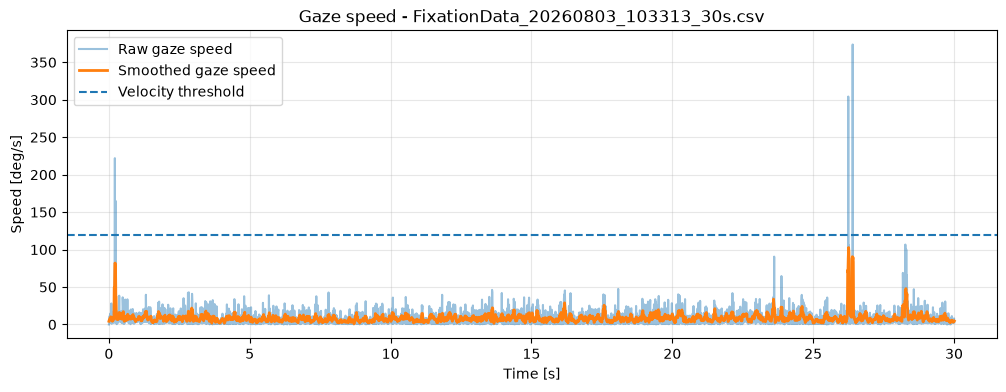

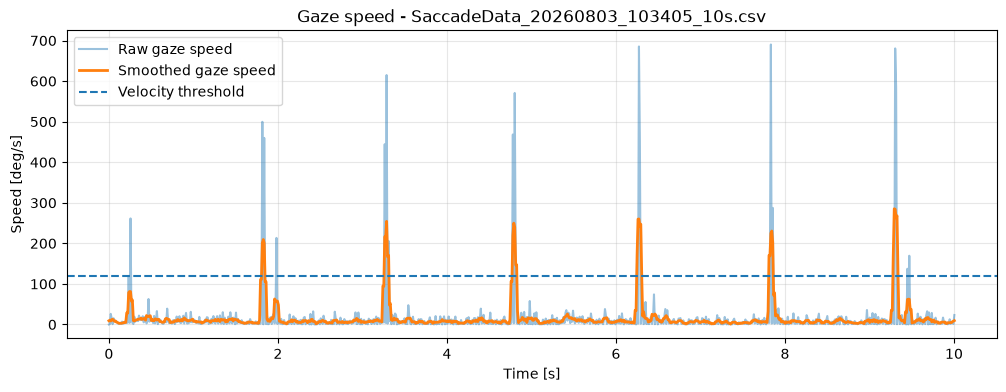

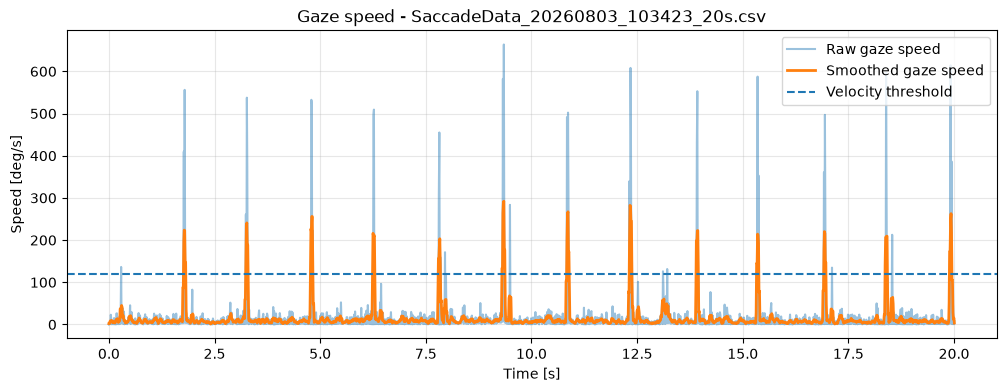

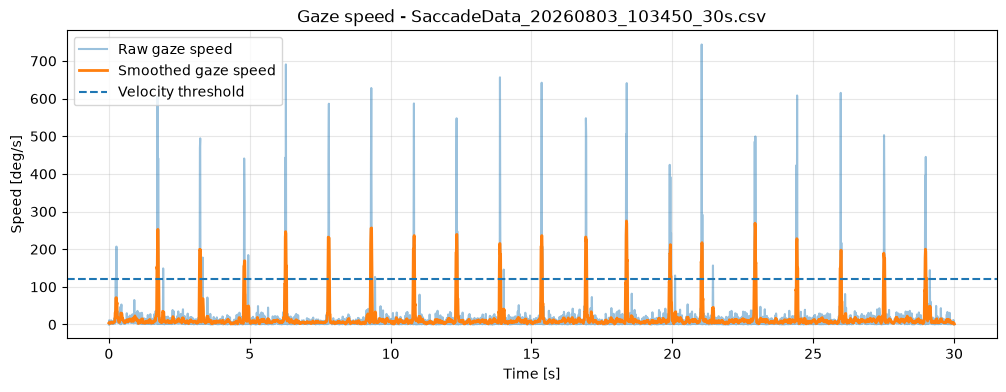

In [4]:
for participant, participant_files in groupby(files, key=lambda path: path.parent.name):
    display(Markdown(f"## {participant.capitalize()}"))
    for path in participant_files:
        recording_samples, _ = analyze_file(path, detection_cfg)
        plot_recording(recording_samples, detection_cfg)
        plt.show()

## Part B -> Dataset evaluation plots

In [5]:
SACCADE_FILE = Path("data/participant_4/SaccadeData_20260729_110441_20s.csv")
BLINK_FILE = Path("data/participant_4/BlinkData_20260729_110615_20s.csv")
FIXATION_FILE = Path("data/participant_4/FixationData_20260729_110316_20s.csv")

thesis_scenario_cfg = ScenarioConfig()

thesis_result = run_analysis(detection_cfg, thesis_scenario_cfg)
all_samples = pd.concat(thesis_result.samples.values(), ignore_index=True)
saccade_samples, saccade_events = analyze_file(SACCADE_FILE, detection_cfg)
blink_samples, _ = analyze_file(BLINK_FILE, detection_cfg)
fixation_samples, fixation_events = analyze_file(FIXATION_FILE, detection_cfg)
expected_saccades = build_expected_saccades(saccade_samples)
expected_blinks = build_expected_blinks(blink_samples, thesis_scenario_cfg)

### P1 — Angular velocity histogram

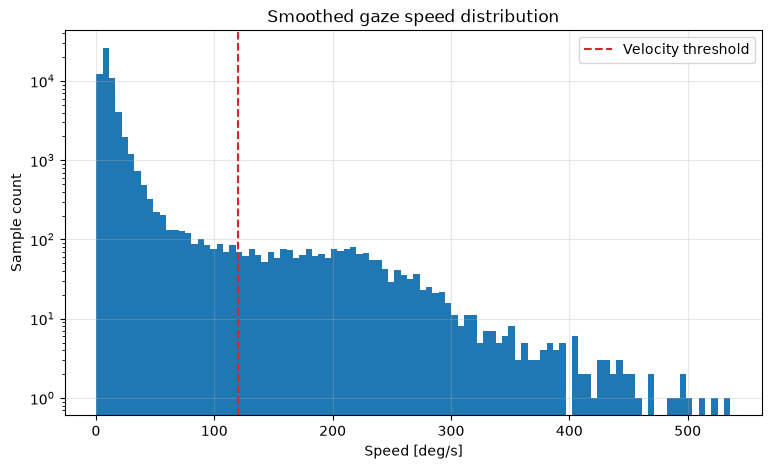

In [6]:
plot_speed_histogram(all_samples, detection_cfg);

### P2 — Detected events and target jumps

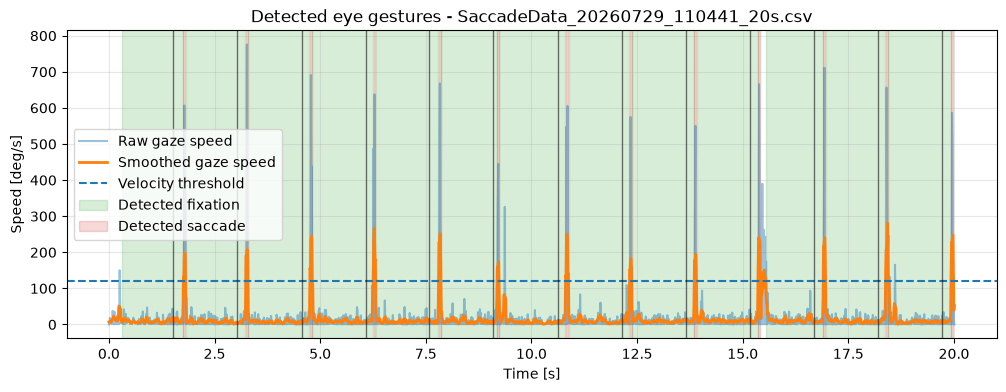

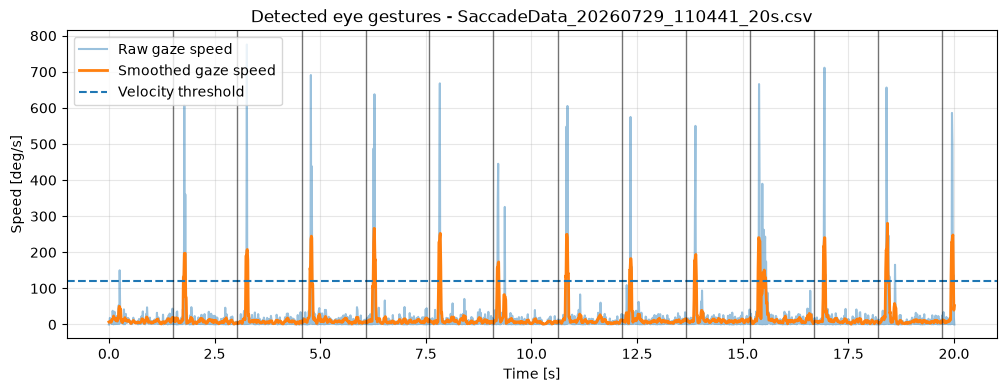

In [7]:
# detected-event coloring enabled
plot_detected_events(
    saccade_samples,
    saccade_events,
    detection_cfg,
    expected_saccades["expected_time_s"],
    show_detected_events=True,
)
# detected-event coloring disabled
plot_detected_events(
    saccade_samples,
    saccade_events,
    detection_cfg,
    expected_saccades["expected_time_s"],
    show_detected_events=False,
);

### P3 — Blink signal and metronome markers

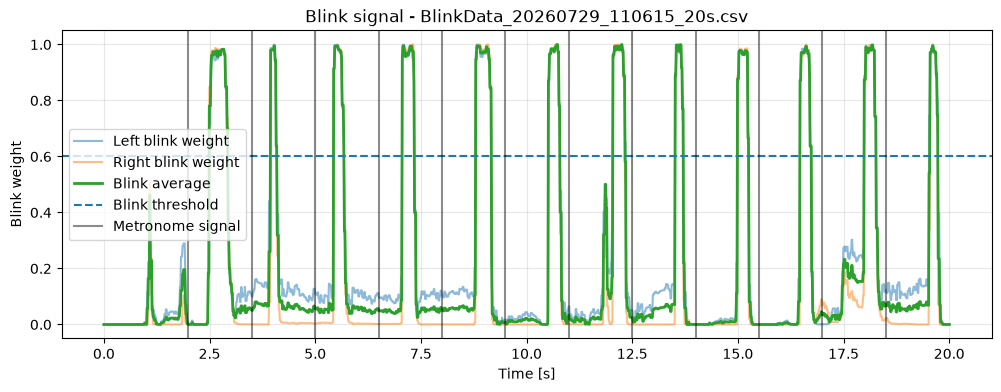

In [8]:
plot_blink_signal(blink_samples, detection_cfg, expected_blinks["expected_time_s"]);

### P4 — Fixation recording timeline

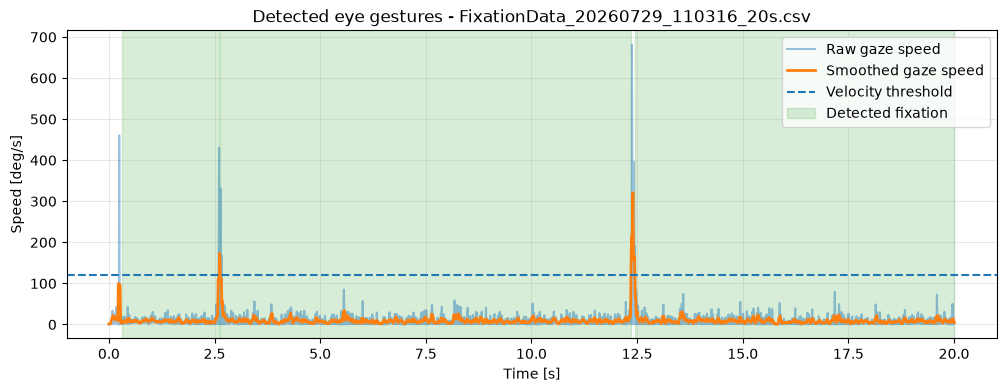

In [9]:
plot_detected_events(fixation_samples, fixation_events, detection_cfg);

### P5a — Saccade direction scatter (single recording)

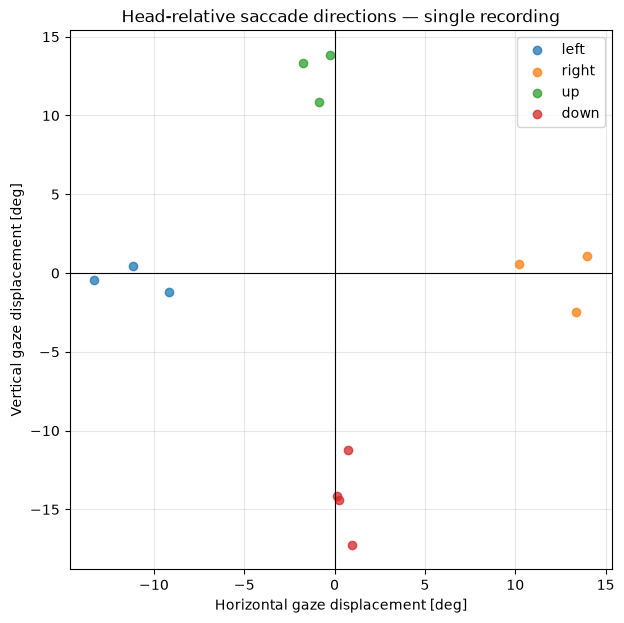

In [10]:
plot_saccade_directions(
    saccade_events,
    "Head-relative saccade directions — single recording",
);

### P5b — Saccade direction scatter (full dataset)

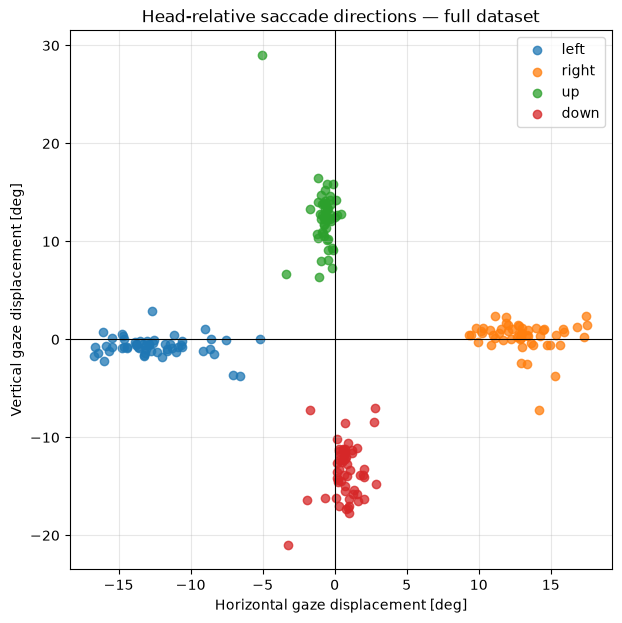

In [11]:
plot_saccade_directions(
    thesis_result.events[thesis_result.events["gesture"] == "saccade"],
    "Head-relative saccade directions — full dataset",
);

### P6 — Velocity threshold sweep

participant,participant_1,participant_2,participant_3,participant_4,participant_5
velocity_threshold_deg_s,,,,,
40,0.800,0.785,0.672,0.893,0.943
60,0.727,0.804,0.678,0.895,0.943
80,0.800,0.804,0.695,0.895,0.943
100,1.000,0.819,0.709,0.927,0.935
120,0.889,0.819,0.731,0.933,0.943
140,1.000,0.808,0.763,0.923,0.933
160,1.000,0.843,0.733,0.898,0.913
180,1.000,0.833,0.641,0.800,0.854


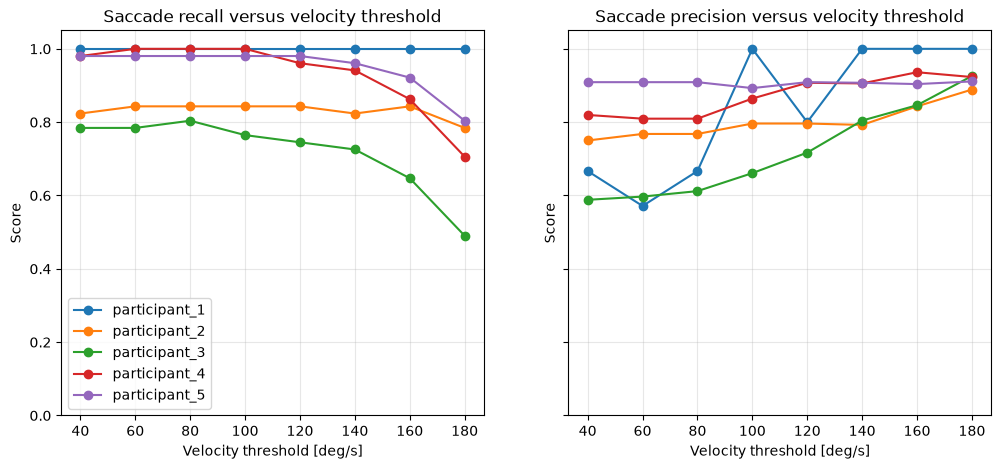

In [12]:
sweep_rows = []
for threshold in range(40, 181, 20):
    sweep_result = run_analysis(
        DetectionConfig(velocity_threshold_deg_s=float(threshold)),
        thesis_scenario_cfg,
    )
    by_participant = summarize_evaluation_by_participant(
        build_saccade_evaluation(sweep_result.saccade_matches, sweep_result.events)
    )
    by_participant["velocity_threshold_deg_s"] = threshold
    sweep_rows.append(by_participant)

sweep = pd.concat(sweep_rows, ignore_index=True)

display(
    sweep.pivot(
        index="velocity_threshold_deg_s", columns="participant", values="f1"
    ).round(3)
)
plot_threshold_sweep(sweep);